<a href="https://colab.research.google.com/github/SusanLL/Project/blob/main/House_Prices_Advanced_Regression_Techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Library and Data**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LassoCV
from sklearn.metrics import make_scorer
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor

# XGBoost (strong baseline); install if missing
try:
    import xgboost as xgb
except ImportError:
    !pip -q install xgboost
    import xgboost as xgb

RANDOM_STATE = 42
N_SPLITS = 5
CV = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
rmse_scorer = make_scorer(lambda y, yhat: np.sqrt(mean_squared_error(y, yhat)), greater_is_better=False)

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
!pip install -q kaggle

In [3]:
!mkdir ~/.kaggle

In [4]:
!cp "/content/drive/MyDrive/Colab Notebooks/Kaggle/kaggle.json" ~/.kaggle/

In [5]:
!chmod 600 ~/.kaggle/kaggle.json

In [6]:
!kaggle competitions download -c house-prices-advanced-regression-techniques

  0% 0.00/199k [00:00<?, ?B/s]
100% 199k/199k [00:00<00:00, 398MB/s]


In [7]:
!unzip house-prices-advanced-regression-techniques.zip

Archive:  house-prices-advanced-regression-techniques.zip
  inflating: data_description.txt    
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               


In [8]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sample_submission = pd.read_csv('sample_submission.csv')

# **Review Data**

In [9]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [10]:
test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [11]:
train.shape, test.shape

((1460, 81), (1459, 80))

In [12]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [13]:
for col in train.select_dtypes(include=['object']).columns:
  print(f"Value counts for column: {col}")
  display(train[col].value_counts())
  print("\n")

Value counts for column: MSZoning


,count
MSZoning,
RL,1151
RM,218
FV,65
RH,16
C (all),10




Value counts for column: Street


,count
Street,
Pave,1454
Grvl,6




Value counts for column: Alley


...

,count
MiscFeature,
Shed,49
Gar2,2
Othr,2
TenC,1




Value counts for column: SaleType


,count
SaleType,
WD,1267
New,122
COD,43
ConLD,9
ConLI,5
ConLw,5
CWD,4
Oth,3
Con,2




Value counts for column: SaleCondition


,count
SaleCondition,
Normal,1198
Partial,125
Abnorml,101
Family,20
Alloca,12
AdjLand,4


In [14]:
mappings = {}
for col in train.select_dtypes(include=['object']).columns:
    train[col] = train[col].fillna("Missing")
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col])
    mappings[col] = dict(zip(le.classes_, le.transform(le.classes_)))

# Show all mappings
for col, mapping in mappings.items():
    print(f"{col} mapping: {mapping}\n")


MSZoning mapping: {'C (all)': np.int64(0), 'FV': np.int64(1), 'RH': np.int64(2), 'RL': np.int64(3), 'RM': np.int64(4)}

Street mapping: {'Grvl': np.int64(0), 'Pave': np.int64(1)}

Alley mapping: {'Grvl': np.int64(0), 'Missing': np.int64(1), 'Pave': np.int64(2)}

LotShape mapping: {'IR1': np.int64(0), 'IR2': np.int64(1), 'IR3': np.int64(2), 'Reg': np.int64(3)}

LandContour mapping: {'Bnk': np.int64(0), 'HLS': np.int64(1), 'Low': np.int64(2), 'Lvl': np.int64(3)}

Utilities mapping: {'AllPub': np.int64(0), 'NoSeWa': np.int64(1)}

LotConfig mapping: {'Corner': np.int64(0), 'CulDSac': np.int64(1), 'FR2': np.int64(2), 'FR3': np.int64(3), 'Inside': np.int64(4)}

LandSlope mapping: {'Gtl': np.int64(0), 'Mod': np.int64(1), 'Sev': np.int64(2)}

Neighborhood mapping: {'Blmngtn': np.int64(0), 'Blueste': np.int64(1), 'BrDale': np.int64(2), 'BrkSide': np.int64(3), 'ClearCr': np.int64(4), 'CollgCr': np.int64(5), 'Crawfor': np.int64(6), 'Edwards': np.int64(7), 'Gilbert': np.int64(8), 'IDOTRR': np.int6

In [15]:
display(train.head(3))
print(train.isna().sum().sort_values(ascending=False).head(5))
print(train['SalePrice'].describe())

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,3,65.0,8450,1,1,3,3,0,...,0,3,2,1,0,2,2008,8,4,208500
1,2,20,3,80.0,9600,1,1,3,3,0,...,0,3,2,1,0,5,2007,8,4,181500
2,3,60,3,68.0,11250,1,1,0,3,0,...,0,3,2,1,0,9,2008,8,4,223500


LotFrontage    259
GarageYrBlt     81
MasVnrArea       8
Id               0
MSSubClass       0
dtype: int64
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [16]:
train = train.fillna(0)
# print(train.isna().sum().sort_values(ascending=False).head(5))

In [17]:
train = train.drop(columns=['Id'])

/tmp/ipython-input-3058139592.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train['SalePrice']);


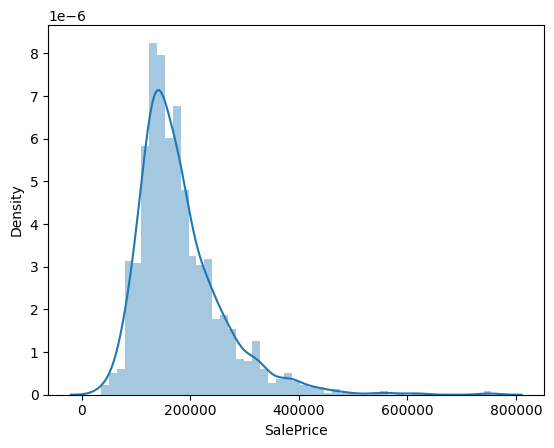

In [18]:
sns.histplot(train['SalePrice'], bins=10, kde=True, stat='density');


# Task
Perform feature selection on the dataset by calculating feature importances, visualizing them, selecting the top features, and creating new datasets with only the selected features.

## Calculate feature importances

### Subtask:
Use a model (like RandomForest or a tree-based model) to calculate the importance of each feature.


**Reasoning**:
Instantiate and fit a RandomForestRegressor model to calculate feature importances and store them.



In [19]:
X = train.drop(columns=['SalePrice'])
y = train['SalePrice']

model = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
model.fit(X, y)
importances = model.feature_importances_

## Visualize feature importances

### Subtask:
Create a bar plot to visualize the calculated feature importances.


**Reasoning**:
Create a pandas Series of feature importances, sort it, and plot the top 20 in a bar chart to visualize their impact.



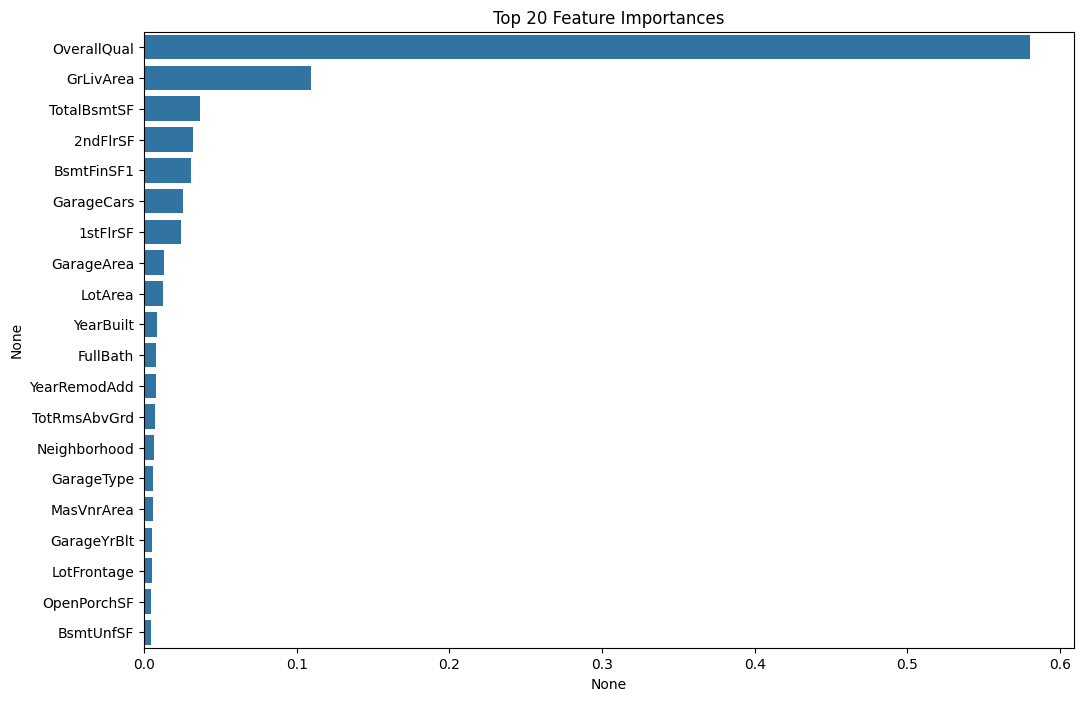

In [20]:
feature_importances = pd.Series(importances, index=X.columns)
feature_importances = feature_importances.sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=feature_importances.head(20), y=feature_importances.head(20).index)
plt.title('Top 20 Feature Importances')
plt.show()

**Reasoning**:
The previous code failed because `matplotlib.pyplot` was not imported. Import `matplotlib.pyplot` and regenerate the code to create and display the bar plot of feature importances.



## Select top features

### Subtask:
Based on the visualization and importance scores, select the top N features.


**Reasoning**:
Select the top N features based on the feature importances and create a list of their names. A common approach is to select features with importance above a certain threshold or simply pick a top number of features that capture most of the variance. Based on the plot, the top 20 features seem to have significantly higher importance than the rest, so I will select the top 20 features.



In [ ]:
num_top_features = 20
selected_features = feature_importances.head(num_top_features).index.tolist()
print("Selected top features:")
print(selected_features)

Selected top features:
['OverallQual', 'GrLivArea', 'TotalBsmtSF', '2ndFlrSF', 'BsmtFinSF1', 'GarageCars', '1stFlrSF', 'GarageArea', 'LotArea', 'YearBuilt', 'FullBath', 'YearRemodAdd', 'TotRmsAbvGrd', 'Neighborhood', 'GarageType', 'MasVnrArea', 'GarageYrBlt', 'LotFrontage', 'OpenPorchSF', 'BsmtUnfSF']


## Filter the dataset

### Subtask:
Create new training and testing datasets containing only the selected features.


**Reasoning**:
Create new training and testing dataframes with only the selected features and display the head of each to verify.



**Reasoning**:
The previous command failed because `X_test_raw` was not defined. I need to load the test data again and assign it to `X_test_raw` before selecting the features.



In [ ]:
test = pd.read_csv('test.csv')
X_test_raw = test.drop(columns=['Id'])

# Apply the same preprocessing as done for the training data
# Fill missing categorical values with "Missing" and apply Label Encoding using the mappings from the training data
for col in X_test_raw.select_dtypes(include=['object']).columns:
    X_test_raw[col] = X_test_raw[col].fillna("Missing")
    if col in mappings: # Use the mappings from the training data
        # Handle potential new categories in test data not in train data
        X_test_raw[col] = X_test_raw[col].map(mappings[col]).fillna(len(mappings[col])).astype(int)
    else: # If a categorical column in test is not in train, treat as a new category
         le = LabelEncoder()
         X_test_raw[col] = le.fit_transform(X_test_raw[col])


# Fill remaining missing numerical values with 0 (as done for train)
X_test_raw = X_test_raw.fillna(0)


X_train_selected = X[selected_features]
X_test_selected = X_test_raw[selected_features]

print("Head of X_train_selected:")
display(X_train_selected.head())

print("\nHead of X_test_selected:")
display(X_test_selected.head())

Head of X_train_selected:


,OverallQual,GrLivArea,TotalBsmtSF,2ndFlrSF,BsmtFinSF1,GarageCars,1stFlrSF,GarageArea,LotArea,YearBuilt,FullBath,YearRemodAdd,TotRmsAbvGrd,Neighborhood,GarageType,MasVnrArea,GarageYrBlt,LotFrontage,OpenPorchSF,BsmtUnfSF
0,7,1710,856,854,706,2,856,548,8450,2003,2,2003,8,5,1,196.0,2003.0,65.0,61,150
1,6,1262,1262,0,978,2,1262,460,9600,1976,2,1976,6,24,1,0.0,1976.0,80.0,0,284
2,7,1786,920,866,486,2,920,608,11250,2001,2,2002,6,5,1,162.0,2001.0,68.0,42,434
3,7,1717,756,756,216,3,961,642,9550,1915,1,1970,7,6,5,0.0,1998.0,60.0,35,540
4,8,2198,1145,1053,655,3,1145,836,14260,2000,2,2000,9,15,1,350.0,2000.0,84.0,84,490



Head of X_test_selected:


,OverallQual,GrLivArea,TotalBsmtSF,2ndFlrSF,BsmtFinSF1,GarageCars,1stFlrSF,GarageArea,LotArea,YearBuilt,FullBath,YearRemodAdd,TotRmsAbvGrd,Neighborhood,GarageType,MasVnrArea,GarageYrBlt,LotFrontage,OpenPorchSF,BsmtUnfSF
0,5,896,882.0,0,468.0,1.0,896,730.0,11622,1961,1,1961,5,12,1,0.0,1961.0,80.0,0,270.0
1,6,1329,1329.0,0,923.0,1.0,1329,312.0,14267,1958,1,1958,6,12,1,108.0,1958.0,81.0,36,406.0
2,5,1629,928.0,701,791.0,2.0,928,482.0,13830,1997,2,1998,6,8,1,0.0,1997.0,74.0,34,137.0
3,6,1604,926.0,678,602.0,2.0,926,470.0,9978,1998,2,1998,7,8,1,20.0,1998.0,78.0,36,324.0
4,8,1280,1280.0,0,263.0,2.0,1280,506.0,5005,1992,2,1992,5,22,1,0.0,1992.0,43.0,82,1017.0


## Summary:

### Data Analysis Key Findings

*   A `RandomForestRegressor` model was successfully used to calculate feature importances for the dataset.
*   The top 20 features based on importance were identified and visualized using a bar plot.
*   The top 20 features selected are: 'OverallQual', 'GrLivArea', 'TotalBsmtSF', '2ndFlrSF', 'BsmtFinSF1', 'GarageCars', '1stFlrSF', 'GarageArea', 'LotArea', 'YearBuilt', 'FullBath', 'YearRemodAdd', 'TotRmsAbvGrd', 'Neighborhood', 'GarageType', 'MasVnrArea', 'GarageYrBlt', 'LotFrontage', 'OpenPorchSF', and 'BsmtUnfSF'.
*   New training and testing datasets (`X_train_selected` and `X_test_selected`) were created containing only these top 20 features.

### Insights or Next Steps

*   The selected features represent the most influential factors in the dataset according to the RandomForest model, suggesting they are likely important predictors for the target variable.
*   These filtered datasets (`X_train_selected` and `X_test_selected`) can now be used for training and evaluating models, potentially improving model performance and reducing complexity by focusing on the most relevant features.


# Model
Using the new selected dataset to run the model to predit the sale prices

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the RandomForestRegressor model
model = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)

# Train the model using the selected features and target variable
model.fit(X_train_selected, y)

print("Model training complete.")

Model training complete.


In [ ]:
# Make predictions on the test set using the trained model
predictions = model.predict(X_test_selected)

# Create a submission DataFrame with 'Id' from the original test data and your predictions
submission_df = pd.DataFrame({'Id': test['Id'], 'SalePrice': predictions})

# Display the head of the submission DataFrame
display(submission_df.head())

# Save the submission DataFrame to a CSV file
submission_df.to_csv('submission.csv', index=False)

,Id,SalePrice
0,1461,127709.83
1,1462,159801.00
2,1463,179809.64
3,1464,182651.65
4,1465,199632.18



Submission file 'submission.csv' created successfully.
